In [ ]:
# librerie

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

import tensorflow as tf
from tensorflow import keras

import math
import random

from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings("ignore")

#### Caricamento dei dati

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = np.load("/content/drive/MyDrive/Colab Notebooks/raman_sim_data.npz")

In [ ]:
#lst = data.files

x_train = data["X_train"]
y_train = data["Y_train"]
x_test = data["X_test"]
y_test = data["Y_test"]

#### Definzione del modello: autoencoder

In [ ]:
inputs=keras.Input(shape=(400,1))

#encoder
x = keras.layers.Conv1D(32, activation="relu", kernel_size=3, padding="same")(inputs)
x = keras.layers.MaxPooling1D(2, padding="same")(x)
x = keras.layers.Conv1D(16, activation="relu", kernel_size=3, padding="same")(x)
x = keras.layers.MaxPooling1D(2, padding="same")(x)
x = keras.layers.Conv1D(8, activation="relu", kernel_size=3, padding="same")(x)
z = keras.layers.MaxPooling1D(2, padding="same")(x)
#decoder
x = keras.layers.Conv1D(8, activation="relu", kernel_size=3, padding="same")(z)
x = keras.layers.UpSampling1D(2)(x)
x = keras.layers.Conv1D(16, activation="relu", kernel_size=3, padding="same")(x)
x = keras.layers.UpSampling1D(2)(x)
x = keras.layers.Conv1D(32, activation="relu", kernel_size=3, padding="same")(x)
x = keras.layers.UpSampling1D(2)(x)

decoded = keras.layers.Conv1D(1, 3, activation="sigmoid", padding="same")(x)


#definisco il modello
autoencoder = keras.Model(inputs=inputs, outputs=decoded, name="DAE")

autoencoder.summary()

Model: "DAE"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 400, 1)]          0         
_________________________________________________________________
conv1d (Conv1D)              (None, 400, 32)           128       
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 200, 32)           0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 200, 16)           1552      
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 100, 16)           0         
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 100, 8)            392       
_________________________________________________________________
max_pooling1d_2 (MaxPooling1 (None, 50, 8)             0       

#### Training del modello

In [ ]:
model_checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=('AE_best_'),
        monitor='val_loss',
        save_weights_only=True,
        save_best_only=True,
        save_freq='epoch')

callbacks = [model_checkpoint]

In [ ]:
autoencoder.compile(optimizer="adam",
                    loss='binary_crossentropy',
                    metrics="mse")
history_ae = autoencoder.fit(x_train, y_train, epochs=600, batch_size=32, validation_split=0.2, shuffle=True, verbose=1, callbacks=callbacks)

Epoch 1/600
200/200 [==============================] - 6s 13ms/step - loss: 0.0326 - mse: 1.7140e-05 - val_loss: 0.0325 - val_mse: 1.0592e-05
Epoch 2/600
200/200 [==============================] - 2s 12ms/step - loss: 0.0324 - mse: 9.9858e-06 - val_loss: 0.0325 - val_mse: 1.0472e-05
Epoch 3/600
200/200 [==============================] - 2s 12ms/step - loss: 0.0325 - mse: 1.0212e-05 - val_loss: 0.0325 - val_mse: 1.1349e-05
Epoch 4/600
200/200 [==============================] - 2s 12ms/step - loss: 0.0325 - mse: 1.0658e-05 - val_loss: 0.0325 - val_mse: 1.0885e-05
Epoch 5/600
200/200 [==============================] - 2s 12ms/step - loss: 0.0325 - mse: 1.0464e-05 - val_loss: 0.0325 - val_mse: 1.1137e-05
Epoch 6/600
200/200 [==============================] - 2s 12ms/step - loss: 0.0325 - mse: 1.0526e-05 - val_loss: 0.0325 - val_mse: 1.0132e-05
Epoch 7/600
200/200 [==============================] - 2s 12ms/step - loss: 0.0325 - mse: 1.0824e-05 - val_loss: 0.0325 - val_mse: 1.4421e-05
Epoch 

#### Visualizzazione della mse e della loss per il training e validation set

In [ ]:
history_dict = history_ae.history
loss = history_dict["loss"]
val_loss = history_dict["val_loss"]
MSE = history_ae.history["mse"]
val_MSE = history_ae.history['val_mse']

epochs_range = range(1, len(loss) + 1)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, MSE, label='Training MSE')
plt.plot(epochs_range, val_MSE, label='Validation MSE')
plt.legend(loc='upper right')
plt.title('Training and Validation mse')
plt.ylim((0,1e-4))

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation loss')
plt.legend(loc='upper right')
plt.ylim((0, 0.05))

plt.show()

#### Testing del modello

In [ ]:
autoencoder.load_weights("/content/drive/MyDrive/Colab Notebooks/AE_best_")

In [ ]:
predict = autoencoder.predict(x_test)

In [ ]:
def calculate_psnr(img1, img2, max_value=1):
  """"Calculating peak signal-to-noise ratio (PSNR) between two images."""
  mse = np.mean((np.array(img1, dtype=np.float32) - np.array(img2, dtype=np.float32)) ** 2)
  if mse == 0:
    return 100
  return 20 * np.log10(max_value / (np.sqrt(mse)))

#### Funzioni custom per i picchi

Funzione custom per la determinazione dei massimi locali

In [ ]:
def local_max(y, dist=10, soglia=0, sens=5):
  max = []
  for x in range(sens, len(y)-sens):
    realMax = True
    for i in range(-sens, sens+1):
      if i != 0:
        realMax = y[x] > y[x+i] and realMax
    if realMax and y[x] > soglia and (len(max) == 0 or x - max[-1] > dist):
      max.append(x)
  max = np.array(max)
  return max

Funzione custom per la classificazione dei picchi

In [ ]:
def near_peaks(peaks_pred, peaks_true, dist=5):
  n_peaks_pred = []
  n_peaks_true = []
  for i in range(len(peaks_pred)):
    n_peaks_pred.append([1])
    n_peaks_true.append([1])
    for p in range(len(peaks_pred[i]) - 1):
      if abs(peaks_pred[i][p] - peaks_pred[i][p+1]) < dist:
        n_peaks_pred[i][-1] += 1
      else:
        n_peaks_pred[i].append(1)
    for p in range(len(peaks_true[i]) - 1):
      if abs(peaks_true[i][p] - peaks_true[i][p+1]) < dist:
        n_peaks_true[i][-1] += 1
      else:
        n_peaks_true[i].append(1)
  return [n_peaks_pred, n_peaks_true]

##### prove della funzione local_max

In [ ]:
axis_x = np.linspace(1, 400, 400)

#azzero i valori nell'array del test set che sono sotto una certa soglia
zero = (y_test[0] < 5e-3)
y_test[0, zero] = 0

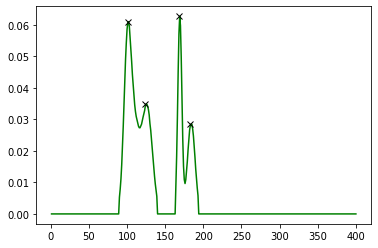

In [ ]:
#massimi per il ground truth reale (test set)
maxima = local_max(y_test[0])

#plot di un elemento del test set con i max trovati
plt.plot(axis_x, y_test[0,:], c="green")
plt.plot(maxima, y_test[0, maxima], "x", c="black")

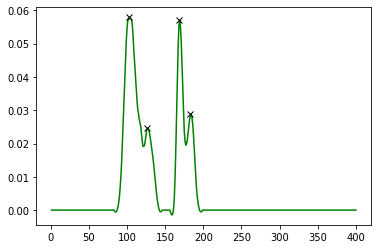

In [ ]:
#azzero i valori nell'array delle previsioni che sono sotto una certa soglia
zero_3 = (predict[0] < 5e-3)
predict[0, zero_3] = 0

#smoothing della funzione predetta
smooth = scipy.signal.savgol_filter(predict[0].squeeze(), 13, 3)
maxima_3 = local_max(smooth)

#plot di un elemento del test set con i max trovati e confronto pre e dopo smoothing
plt.plot(axis_x,smooth, c="green")
plt.plot(maxima_3,smooth[maxima_3], "x", c="black")

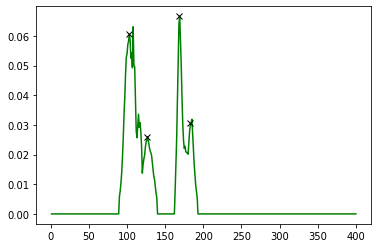

In [ ]:
plt.plot(axis_x, predict[0,:], c="green")
plt.plot(maxima_3, predict[0, maxima_3], "x", c="black")

#### Plot dei risultati del test set e confronto con l'andamento aspettato per 6 grafici random

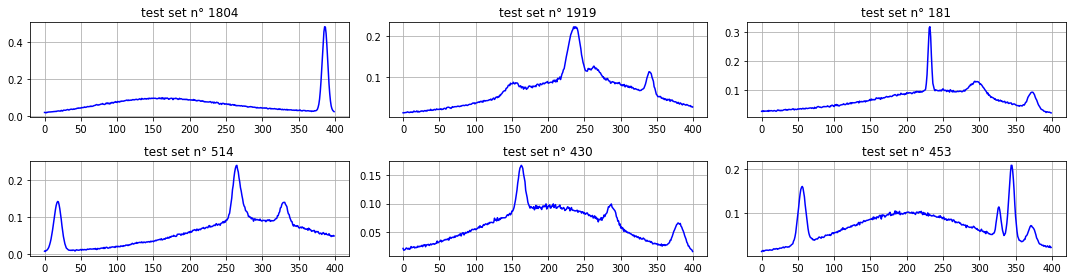

In [ ]:
img_number = np.random.randint(0, 2000, size=6)

plt.figure(figsize = (15, 4))
for i in range(len(img_number)):
  plt.subplot(2, 3, i+1)
  plt.plot(x_test[img_number[i]], c='blue')
  plt.title(f'test set n° {img_number[i]}')
  plt.grid()
plt.tight_layout()
plt.savefig('testset.pdf', format='pdf')

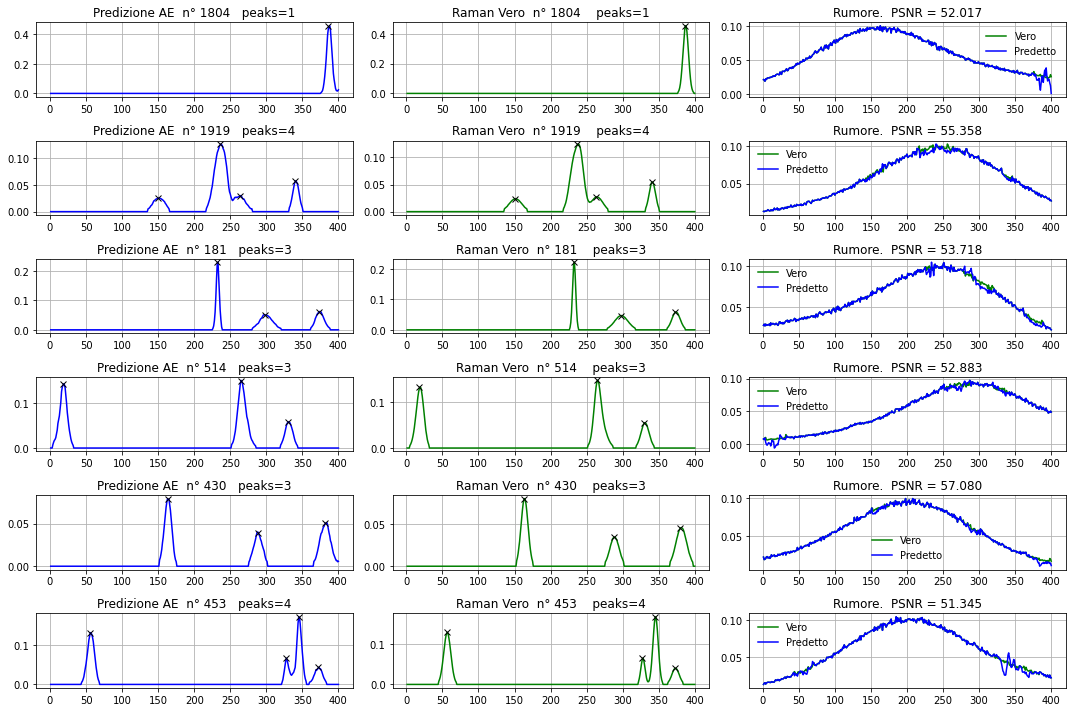

In [ ]:
plt.figure(figsize = (15, 10))
l = 0
for i in img_number:
  temp_true = np.squeeze(y_test, axis=2)
  #azzero i valori nell'array del test set che sono sotto una certa soglia
  zero = (temp_true[i] < 5e-3)
  temp_true[i, zero] = 0
  nmb_peaks_true = local_max(temp_true[i,:])

  temp_pred = np.squeeze(predict, axis=2)
  #azzero i valori nell'array del test set che sono sotto una certa soglia
  zero = (temp_pred[i] < 5e-3)
  temp_pred[i, zero] = 0
  #smoothing della funzione predetta
  smooth = scipy.signal.savgol_filter(temp_pred[i].squeeze(), 13, 3)
  nmb_peaks_pred = local_max(smooth)

  plt.subplot(len(img_number), 3, l+1)
  plt.title(f"Predizione AE  n° {i}   peaks={len(nmb_peaks_pred)}")
  plt.grid()
  plt.plot(axis_x, predict[i,:], c="blue")
  plt.plot(nmb_peaks_pred, predict[i, nmb_peaks_pred], "x", c="black")

  plt.subplot(len(img_number), 3, l+2)
  plt.title(f"Raman Vero  n° {i}    peaks={len(nmb_peaks_true)}")
  plt.grid()
  plt.plot(axis_x, y_test[i,:], c="green")
  plt.plot(nmb_peaks_true, y_test[i, nmb_peaks_true], "x", c="black")

  plt.subplot(len(img_number), 3, l+3)
  psnr = calculate_psnr(x_test[i,:] - y_test[i,:], x_test[i] - predict[i,:])
  plt.title("Rumore.  PSNR = {:3.3f}".format(psnr))
  plt.grid()
  plt.plot(axis_x, x_test[i,:] - y_test[i,:], c="green", label="Vero")
  plt.plot(axis_x, x_test[i] - predict[i,:], c="blue", label="Predetto")
  plt.legend(frameon=False)

  l += 3
plt.tight_layout()
plt.savefig('6random.pdf', format='pdf')

#### Analisi dell'andamento dei picchi per il test set

In [ ]:
# liste contenenti le ascisse dei picchi predetti e veri
peaks_pred = []
peaks_true = []

for i in tqdm(range(len(temp_true))):
  #smoothing della funzione predetta
  smooth_pred = scipy.signal.savgol_filter(temp_pred[i].squeeze(), 13, 3)

  #azzero i valori nell'array del test set che sono sotto una certa soglia
  zero = (temp_true < 5e-3)
  temp_true[zero] = 0
  zero = (smooth_pred < 5e-3)
  smooth_pred[zero] = 0

  # uso local_max per inserire le ascisse dei picchi predetti e veri nelle liste
  peaks_true.append(local_max(temp_true[i]))
  peaks_pred.append(local_max(smooth_pred))

# classificazione dei picchi vicini
n_peaks_pred, n_peaks_true = near_peaks(peaks_pred, peaks_true, 30)

In [ ]:
nulli = []      # indici spettri con differenza nulla tra picchi predetti e reali

singoli = []    # indici spettri con differenza di 1 tra picchi predetti e reali
doppi = []      # indici spettri con differenza di 2 tra picchi predetti e reali
tripli = []     # indici spettri con differenza di 3 tra picchi predetti e reali
quadrupli = []  # indici spettri con differenza di 4 tra picchi predetti e reali

for i in range(len(peaks_pred)):
  if len(peaks_pred[i]) == len(peaks_true[i]):   #1861 predizioni corrette
    nulli.append(i)
  elif abs(len(peaks_pred[i]) - len(peaks_true[i])) == 1:
    singoli.append(i)
  elif abs(len(peaks_pred[i]) - len(peaks_true[i])) == 2:
    doppi.append(i)
  elif abs(len(peaks_pred[i]) - len(peaks_true[i])) == 3:
    tripli.append(i)
  elif abs(len(peaks_pred[i]) - len(peaks_true[i])) == 4:
    quadrupli.append(i)

print('nulli:', len(nulli), '\nsingoli:', len(singoli), '\ndoppi:', len(doppi), '\ntripli:', len(tripli), '\nquadrupli:', len(quadrupli))

nulli: 1861 
singoli: 135 
doppi: 4 
tripli: 0 
quadrupli: 0


##### Plot dei 5 spettri, scelti random, che hanno una differenza di 1 picco tra la predizione del modello e il risultato vero

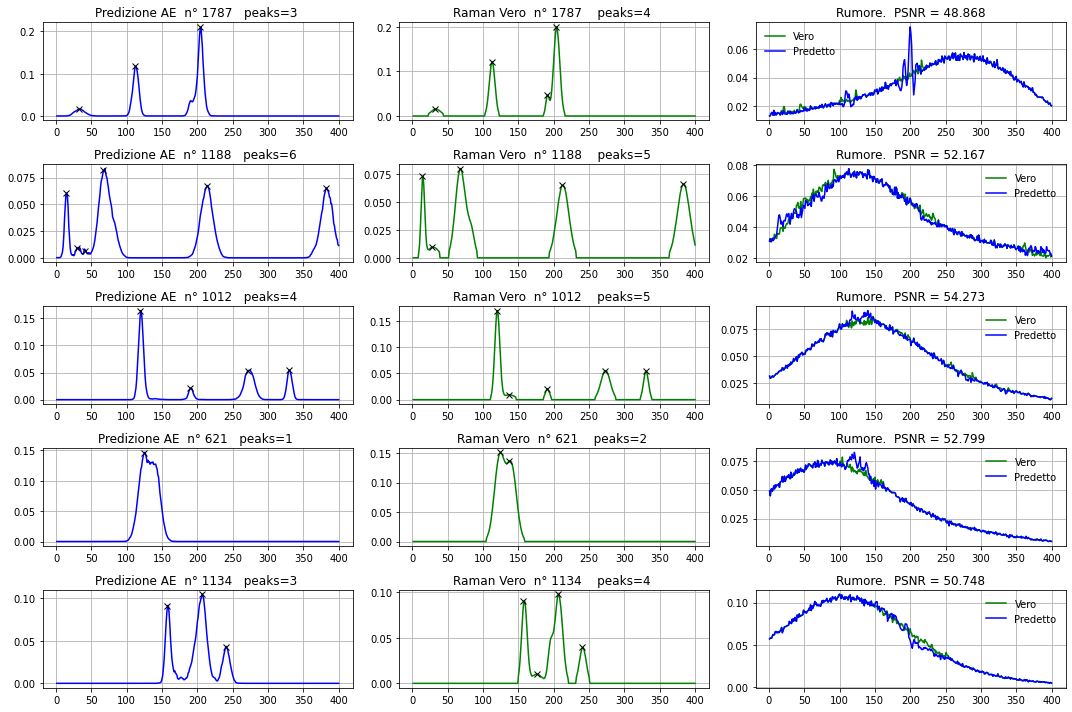

In [ ]:
img_number = np.random.randint(0, len(singoli), size=5)

l = 0
plt.figure(figsize = (15, 10))
for i in img_number:
  plt.subplot(len(img_number), 3, l+1)
  plt.title(f"Predizione AE  n° {singoli[i]}   peaks={len(peaks_pred[singoli[i]])} ")
  plt.grid()
  plt.plot(axis_x, predict[singoli[i],:], c="blue")
  plt.plot(peaks_pred[singoli[i]], predict[singoli[i], peaks_pred[singoli[i]]], "x", c="black")


  plt.subplot(len(img_number), 3, l+2)
  plt.title(f"Raman Vero  n° {singoli[i]}    peaks={len(peaks_true[singoli[i]])} ")
  plt.grid()
  plt.plot(axis_x, y_test[singoli[i],:], c="green")
  plt.plot(peaks_true[singoli[i]], y_test[singoli[i], peaks_true[singoli[i]]], "x", c="black")


  plt.subplot(len(img_number), 3, l+3)
  psnr = calculate_psnr(x_test[singoli[i],:] - y_test[singoli[i],:], x_test[singoli[i]] - predict[singoli[i],:])
  plt.title("Rumore.  PSNR = {:3.3f}".format(psnr))
  plt.grid()
  plt.plot(axis_x, x_test[singoli[i],:] - y_test[singoli[i],:], c="green", label="Vero")
  plt.plot(axis_x, x_test[singoli[i],:] - predict[singoli[i],:], c="blue", label="Predetto")
  plt.legend(frameon=False)

  l += 3
plt.tight_layout()
plt.savefig('singoli.pdf', format='pdf')

##### Plot di tutti e 4 gli spettri che hanno una differenza di 2 picchi tra la predizione del modello e il risultato vero

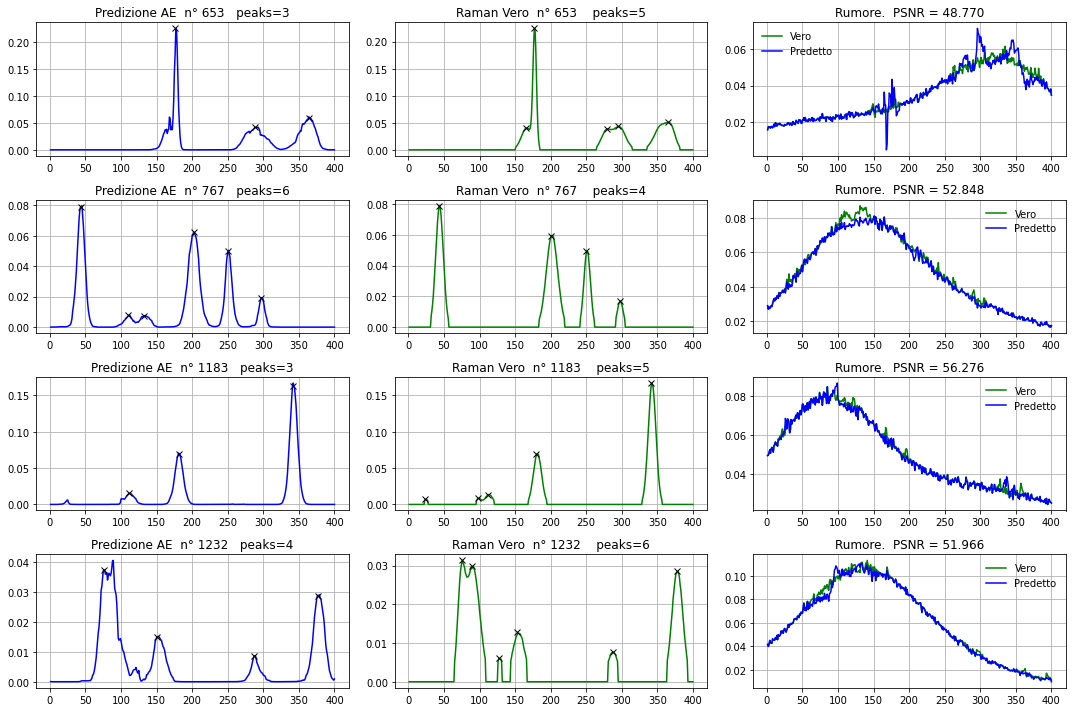

In [ ]:
l = 0
plt.figure(figsize = (15, 10))
for i in doppi:
  plt.subplot(len(doppi), 3, l+1)
  plt.title(f"Predizione AE  n° {i}   peaks={len(peaks_pred[i])}")
  plt.grid()
  plt.plot(axis_x, predict[i,:], c="blue")
  plt.plot(peaks_pred[i], predict[i, peaks_pred[i]], "x", c="black")


  plt.subplot(len(doppi), 3, l+2)
  plt.title(f"Raman Vero  n° {i}    peaks={len(peaks_true[i])}")
  plt.grid()
  plt.plot(axis_x, y_test[i,:], c="green")
  plt.plot(peaks_true[i], y_test[i,peaks_true[i]], "x", c="black")


  plt.subplot(len(doppi), 3, l+3)
  psnr = calculate_psnr(x_test[i,:] - y_test[i,:], x_test[i] - predict[i,:])
  plt.title("Rumore.  PSNR = {:3.3f}".format(psnr))
  plt.grid()
  plt.plot(axis_x, x_test[i,:] - y_test[i,:], c="green", label="Vero")
  plt.plot(axis_x, x_test[i,:] - predict[i,:], c="blue", label="Predetto")
  plt.legend(frameon=False)

  l += 3
plt.tight_layout()
plt.savefig('doppi.pdf', format='pdf')

Analisi sulla classificazione dei picchi da parte del modello

In [ ]:
correct = 0       # numero di previsioni corrette sulla natura dei picchi
uncorrect = 0     # numero di previsioni sbagliate sulla natura dei picchi

# tipi di picco:  1 singolo, 2 doppio, 3 triplo, 4 quadruplo

correct1 = 0      # numero di volte in cui un picco singolo viene identificato come tale
correct2 = 0      # numero di volte in cui un picco doppio viene identificato come tale
correct3 = 0      # numero di volte in cui un picco triplo viene identificato come tale
correct4 = 0      # numero di volte in cui un picco quadruplo viene identificato come tale

# uncorrect n m   n: tipo di picco predetto,  m: tipo di picco vero
uncorrect12 = 0   # numero di volte in cui un picco singolo viene identificato come doppio
uncorrect21 = 0   # numero di volte in cui un picco doppio viene identificato come singolo
uncorrect13 = 0   # 1 -> 3
uncorrect31 = 0   # 3 -> 1
uncorrect23 = 0   # 2 -> 3
uncorrect32 = 0   # 3 -> 2
uncorrect14 = 0   # 1 -> 4
uncorrect41 = 0   # 4 -> 1
uncorrect24 = 0   # 2 -> 4
uncorrect42 = 0   # 4 -> 2
uncorrect34 = 0   # 3 -> 4
uncorrect43 = 0   # 4 -> 3

# liste con indici degli spettri predetti male
wrong_pred = []
wrong_true = []
wrong_pred_nulli = []   # predetti male con differenza nulla del numero di picchi

# conteggio delle predizioni corrette e sbagliate per ogni spettro
# conteggio della corretta classificazione del tipo di picco
for i in range(len(n_peaks_pred)):
  if len(n_peaks_pred[i]) == len(n_peaks_true[i]):
    correctBool = True
    for p in range(len(n_peaks_pred[i])):
      if n_peaks_pred[i][p] != n_peaks_true[i][p]:
        correctBool = False
      if n_peaks_pred[i][p] == 1 and n_peaks_true[i][p] == 1:
        correct1 += 1
      elif n_peaks_pred[i][p] == 2 and n_peaks_true[i][p] == 2:
        correct2 += 1
      elif n_peaks_pred[i][p] == 3 and n_peaks_true[i][p] == 3:
        correct3 += 1
      elif n_peaks_pred[i][p] == 4 and n_peaks_true[i][p] == 4:
        correct4 += 1

      elif n_peaks_pred[i][p] == 2 and n_peaks_true[i][p] == 1:
        uncorrect21 += 1
      elif n_peaks_pred[i][p] == 1 and n_peaks_true[i][p] == 2:
        uncorrect12 += 1

      elif n_peaks_pred[i][p] == 3 and n_peaks_true[i][p] == 1:
        uncorrect31 += 1
      elif n_peaks_pred[i][p] == 1 and n_peaks_true[i][p] == 3:
        uncorrect13 += 1

      elif n_peaks_pred[i][p] == 3 and n_peaks_true[i][p] == 2:
        uncorrect32 += 1
      elif n_peaks_pred[i][p] == 2 and  n_peaks_true[i][p] == 3:
        uncorrect23 += 1

      elif n_peaks_pred[i][p] == 4 and n_peaks_true[i][p] == 1:
        uncorrect41 += 1
      elif n_peaks_pred[i][p] == 1 and  n_peaks_true[i][p] == 4:
        uncorrect14 += 1

      elif n_peaks_pred[i][p] == 4 and n_peaks_true[i][p] == 2:
        uncorrect42 += 1
      elif n_peaks_pred[i][p] == 2 and  n_peaks_true[i][p] == 4:
        uncorrect24 += 1

      elif n_peaks_pred[i][p] == 4 and n_peaks_true[i][p] == 3:
        uncorrect43 += 1
      elif n_peaks_pred[i][p] == 3 and  n_peaks_true[i][p] == 4:
        uncorrect34 += 1

    if correctBool:
      correct += 1
    else:
      uncorrect += 1
      wrong_pred.append(i)
      wrong_true.append(i)
  else:
    uncorrect += 1
    wrong_pred.append(i)
    wrong_true.append(i)


for i in wrong_pred:
  if i in nulli:
    wrong_pred_nulli.append(i)


tot_peaks = 0
for i in range(len(n_peaks_pred)):
  if len(n_peaks_pred[i]) == len(n_peaks_true[i]):
    tot_peaks += len(n_peaks_pred[i])


print('numero grafici analizzati = 2000')
print(f'correct = {correct}\nuncorrect = {uncorrect}')
print('falsi sbagliati =', len(wrong_pred_nulli))

print(f'\nnumero di picchi analizzati = {tot_peaks}')
print(f'correct1 = {correct1}\ncorrect2 = {correct2}\nuncorrect12 = {uncorrect12}\nuncorrect21 = {uncorrect21}')
print(f'correct3 = {correct3}\nuncorrect13 = {uncorrect13}\nuncorrect31 = {uncorrect31}\nuncorrect23 = {uncorrect23}\nuncorrect32 = {uncorrect32}')
print(f'correct4 = {correct4}\nuncorrect14 = {uncorrect14}\nuncorrect41 = {uncorrect41}\nuncorrect24 = {uncorrect24}\nuncorrect42 = {uncorrect42}\nuncorrect34 = {uncorrect34}\nuncorrect43 = {uncorrect43}')

numero grafici analizzati = 2000
correct = 1823
uncorrect = 177
falsi sbagliati = 38

numero di picchi analizzati = 5079
correct1 = 4536
correct2 = 403
uncorrect12 = 52
uncorrect21 = 31
correct3 = 45
uncorrect13 = 0
uncorrect31 = 0
uncorrect23 = 1
uncorrect32 = 7
correct4 = 3
uncorrect14 = 0
uncorrect41 = 0
uncorrect24 = 0
uncorrect42 = 0
uncorrect34 = 0
uncorrect43 = 1


##### Plot dei falsi sbagliati

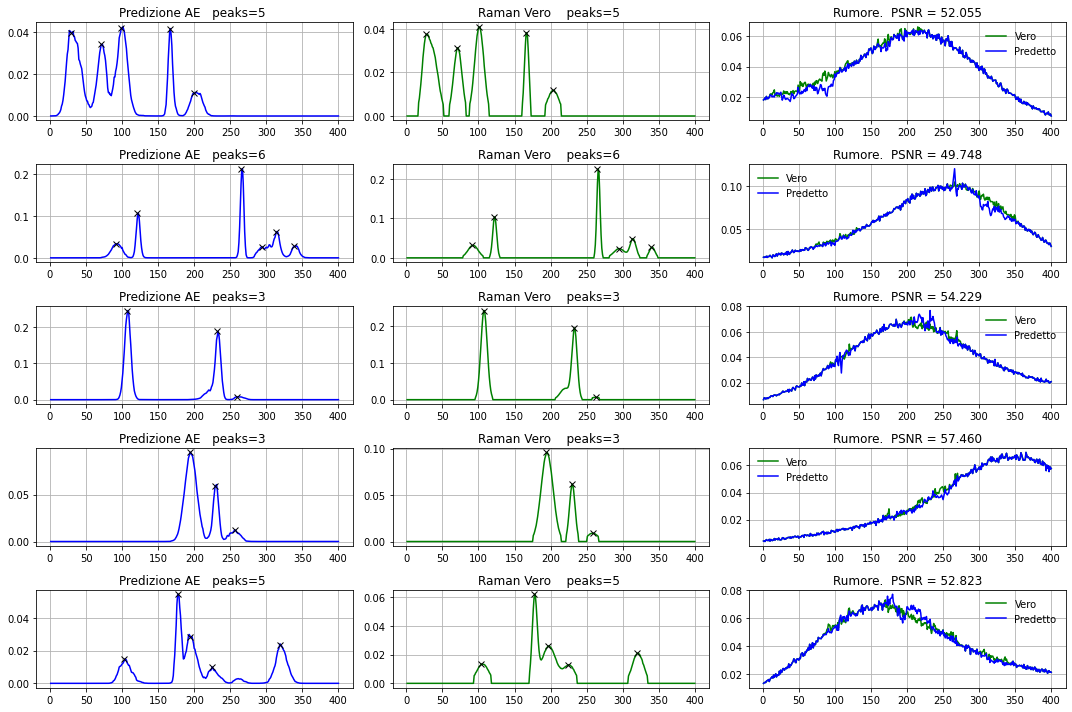

In [ ]:
img_number = np.random.randint(0, len(wrong_pred_nulli), size=5)

l = 0
plt.figure(figsize = (15, 10))
for i in img_number:
  plt.subplot(len(img_number), 3, l+1)
  plt.title("Predizione AE   peaks={:d} ".format(len(peaks_pred[wrong_pred_nulli[i]])))
  plt.grid()
  plt.plot(axis_x, predict[wrong_pred_nulli[i],:], c="blue")
  plt.plot(peaks_pred[wrong_pred_nulli[i]], predict[wrong_pred_nulli[i], peaks_pred[wrong_pred_nulli[i]]], "x", c="black")


  plt.subplot(len(img_number), 3, l+2)
  plt.title("Raman Vero    peaks={:d} ".format(len(peaks_true[wrong_pred_nulli[i]])))
  plt.grid()
  plt.plot(axis_x, y_test[wrong_pred_nulli[i],:], c="green")
  plt.plot(peaks_true[wrong_pred_nulli[i]], y_test[wrong_pred_nulli[i], peaks_true[wrong_pred_nulli[i]]], "x", c="black")


  plt.subplot(len(img_number), 3, l+3)
  psnr = calculate_psnr(x_test[wrong_pred_nulli[i],:] - y_test[wrong_pred_nulli[i],:], x_test[wrong_pred_nulli[i]] - predict[wrong_pred_nulli[i],:])
  plt.title("Rumore.  PSNR = {:3.3f}".format(psnr))
  plt.grid()
  plt.plot(axis_x, x_test[wrong_pred_nulli[i],:] - y_test[wrong_pred_nulli[i],:], c="green", label="Vero")
  plt.plot(axis_x, x_test[wrong_pred_nulli[i],:] - predict[wrong_pred_nulli[i],:], c="blue", label="Predetto")
  plt.legend(frameon=False)

  l += 3
plt.tight_layout()

##### Studio degli spettri per i quali il modello ha predetto lo stesso numero di picchi

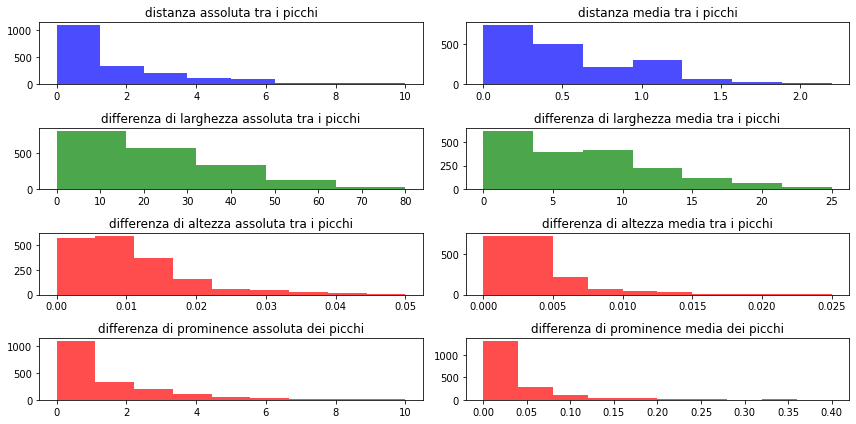

In [ ]:
# liste con larghezza dei picchi degli spettri predetti e veri
width_true = []
width_pred = []
# liste con prominence dei picchi degli spettri predetti e veri
prom_true = []
prom_pred = []

# medie e somma delle differenze di larghezza, altezza e prominence dei picchi tra i predetti e i veri
width_mean = []
width_abs = []
height_mean = []
height_abs = []
peak_distance_mean = []
peak_distance_abs = []
prom_mean = []
prom_abs = []

for i in range(len(peaks_pred)):
  width_true.append(scipy.signal.peak_widths(temp_true[i], peaks_true[i])[0])
  width_pred.append(scipy.signal.peak_widths(temp_pred[i], peaks_pred[i])[0])

  prom_true.append(scipy.signal.peak_prominences(temp_true[i], peaks_true[i])[0])
  prom_pred.append(scipy.signal.peak_prominences(temp_pred[i], peaks_pred[i])[0])

  if len(peaks_pred[i])==len(peaks_true[i]):
    # larghezza dei picchi
    width_diff = abs(width_true[i] - width_pred[i])
    width_mean.append(width_diff.mean())
    width_abs.append(width_diff.sum())
    # altezza dei picchi
    height_diff = abs(temp_true[i,peaks_true[i]] - temp_pred[i,peaks_pred[i]])
    height_mean.append(height_diff.mean())
    height_abs.append(height_diff.sum())
    # distanza tra i picchi
    dist = abs(peaks_pred[i]-peaks_true[i])
    peak_distance_mean.append(dist.mean())
    peak_distance_abs.append(dist.sum())
    # prominence dei picchi
    prom_diff = abs(prom_true[i] - prom_pred[i])
    prom_mean.append(prom_diff.mean())
    prom_abs.append(dist.sum())


plt.figure(figsize = (12, 6))

# con assoluta si intende (diff_altezza_primo_picco + diff_altezza_secondo_picco + ...) su uno stesso spettro raman
# la media è diviso per il numero di picchi per run

# Distanze tra i picchi
plt.subplot(4, 2, 1)
plt.hist(peak_distance_abs, range=(0,10), bins=8, alpha=0.7, color="blue")
plt.title("distanza assoluta tra i picchi")

plt.subplot(4, 2, 2)
plt.hist(peak_distance_mean, range=(0,2.2), bins=7, alpha=0.7, color="blue")
plt.title("distanza media tra i picchi")

# Differenze tra le larghezze dei picchi
plt.subplot(4, 2, 3)
plt.hist(width_abs, bins=5, range=(0,80), alpha=0.7, color="green")
plt.title("differenza di larghezza assoluta tra i picchi")

plt.subplot(4, 2, 4)
plt.hist(width_mean, bins=7, range=(0,25), alpha=0.7, color="green")
plt.title("differenza di larghezza media tra i picchi")

# Differenze tra le altezze dei picchi
plt.subplot(4, 2, 5)
plt.hist(height_abs, bins=9, range=(0,0.05), alpha=0.7, color="red")
plt.title("differenza di altezza assoluta tra i picchi")

plt.subplot(4, 2, 6)
plt.hist(height_mean, bins=10, range=(0,0.025), alpha=0.7, color="red")
plt.title("differenza di altezza media tra i picchi")

# Differenze tra le rominences
plt.subplot(4, 2, 7)
plt.hist(prom_abs, bins=9, range=(0,10), alpha=0.7, color="red")
plt.title("differenza di prominence assoluta dei picchi")

plt.subplot(4, 2, 8)
plt.hist(prom_mean, bins=10, range=(0,0.4), alpha=0.7, color="red")
plt.title("differenza di prominence media dei picchi")


plt.tight_layout()
plt.savefig('hist.pdf', format='pdf')

#### PSNR

##### PSNR su tutto il campione di test

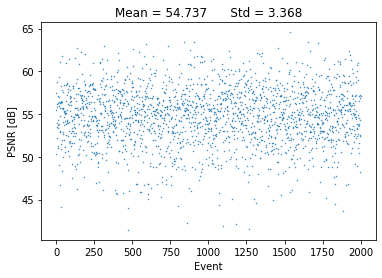

In [ ]:
x = np.linspace(0, 1999, 2000)
psnr = np.zeros(2000)

for i in range(len(y_test)):
  psnr[i] = calculate_psnr(y_test[i,:], predict[i,:])
mean = psnr.mean()
std = psnr.std()

plt.scatter(x, psnr, s=0.2)
plt.title("Mean = {:3.3f}      Std = {:3.3f}".format(mean, std))
plt.ylabel("PSNR [dB]")
plt.xlabel("Event")
plt.savefig('PSNR.pdf', format='pdf')

##### PSNR su nulli, singoli e doppi

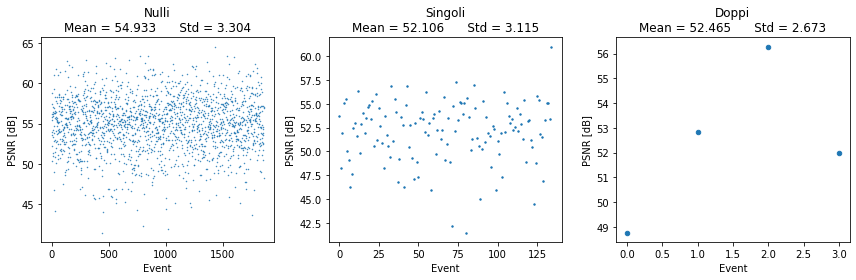

In [ ]:
plt.figure(figsize = (12, 4))


x = np.linspace(0, len(nulli)-1, len(nulli))
psnr = np.zeros(len(nulli))

for i in range(len(nulli)):
  psnr[i] = calculate_psnr(y_test[nulli[i],:], predict[nulli[i],:])
mean = psnr.mean()
std = psnr.std()

plt.subplot(1, 3, 1)
plt.scatter(x, psnr, s=0.2)
plt.title("Nulli\nMean = {:3.3f}      Std = {:3.3f}".format(mean, std))
plt.ylabel("PSNR [dB]")
plt.xlabel("Event")


x = np.linspace(0, len(singoli)-1, len(singoli))
psnr = np.zeros(len(singoli))

for i in range(len(singoli)):
  psnr[i] = calculate_psnr(y_test[singoli[i],:], predict[singoli[i],:])
mean = psnr.mean()
std = psnr.std()

plt.subplot(1, 3, 2)
plt.scatter(x, psnr, s=2)
plt.title("Singoli\nMean = {:3.3f}      Std = {:3.3f}".format(mean, std))
plt.ylabel("PSNR [dB]")
plt.xlabel("Event")


x = np.linspace(0, len(doppi)-1, len(doppi))
psnr = np.zeros(len(doppi))

for i in range(len(doppi)):
  psnr[i] = calculate_psnr(y_test[doppi[i],:], predict[doppi[i],:])
mean = psnr.mean()
std = psnr.std()

plt.subplot(1, 3, 3)
plt.scatter(x, psnr, s=20)
plt.title("Doppi\nMean = {:3.3f}      Std = {:3.3f}".format(mean, std))
plt.ylabel("PSNR [dB]")
plt.xlabel("Event")


plt.tight_layout()
plt.savefig('PSNR012.pdf', format='pdf')